In [13]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [15]:
# 1. Load data (engine='python' and sep='|' handles your format)
df = pd.read_csv("crop_yield_polynomial_regression.csv")

# 2. Clean up columns (drop empty ones from the edges, remove spaces from names)
df = df.dropna(axis=1, how='all')
df.columns = df.columns.str.strip()

# 3. Convert numbers to float (empty spaces become NaN automatically)
num_cols = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare', 'CropYield_tons']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Drop rows where Target (Yield) is missing
df = df.dropna(subset=['CropYield_tons'])

# 5. Fix Missing Features: fill numeric NaNs with the median
for col in ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare']:
    df[col] = df[col].fillna(df[col].median())

# 6. Remove Impossible Outliers (This makes the model learn better!)
df = df[df['Fertilizer_kg_per_hectare'] >= 0]
df = df[df['Fertilizer_kg_per_hectare'] <= 400]   # Removes the 850 and 1200 rows
df = df[df['Water_mm_per_season'] >= 0]           # Removes negative water
df = df[df['Water_mm_per_season'] <= 2000]        # Removes the 8500 row
df = df[df['CropYield_tons'] > 0]                 # Removes the -2.5 row

print("Data cleaned! We have", len(df), "rows left.")

Data cleaned! We have 486 rows left.


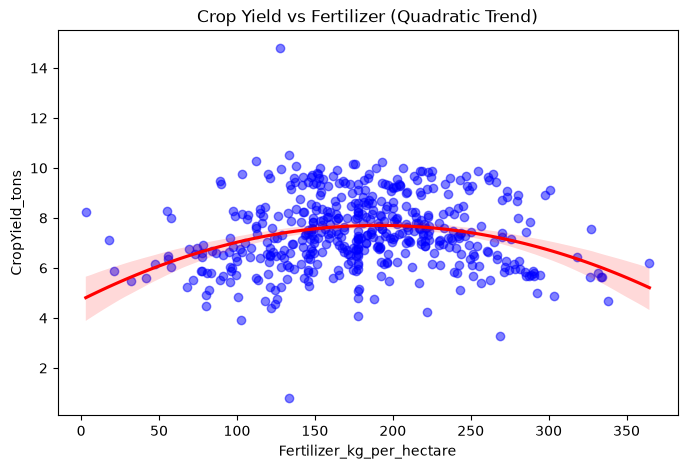

In [16]:
plt.figure(figsize=(8, 5))
# order=2 tells seaborn to fit a degree 2 polynomial line
sns.regplot(data=df, x="Fertilizer_kg_per_hectare", y="CropYield_tons", 
            scatter_kws={"alpha":0.5, "color":"blue"}, 
            line_kws={"color":"red"}, order=2)
plt.title("Crop Yield vs Fertilizer (Quadratic Trend)")
plt.show()

In [17]:
# Set X and y
X = df[['Fertilizer_kg_per_hectare']] # Double brackets keep it as a 2D table
y = df['CropYield_tons']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

degrees = [1, 2, 3]

for d in degrees:
    # 1. Create Polynomial Features
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # 2. Train the Model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # 3. Predict and Evaluate
    y_pred = model.predict(X_test_poly)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Degree {d} -> MAE: {mae:.3f} | R2 Score: {r2:.3f}")

Degree 1 -> MAE: 1.240 | R2 Score: -0.005
Degree 2 -> MAE: 1.135 | R2 Score: 0.135
Degree 3 -> MAE: 1.150 | R2 Score: 0.106


/Users/macbookair/Desktop/ML/VE/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


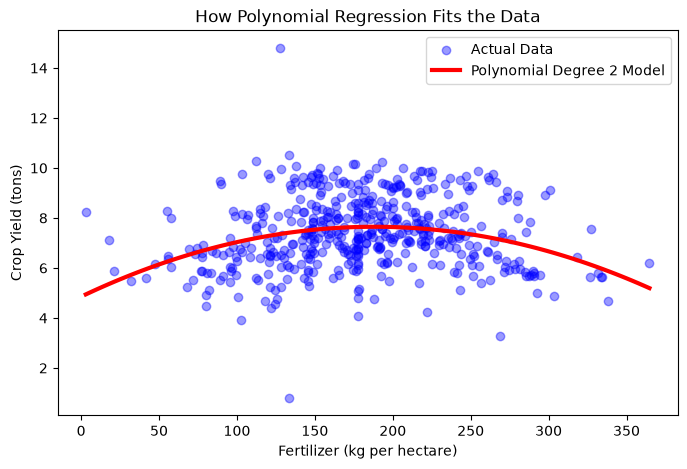

In [18]:
# Train the Degree 2 model again so we can draw it
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

# Create a smooth line of numbers from min to max fertilizer
x_curve = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
# Transform this smooth line using the SAME poly rules
x_curve_poly = poly.transform(x_curve)
# Predict the Yield for the smooth line
y_curve = model.predict(x_curve_poly)

# Plot it!
plt.figure(figsize=(8, 5))
# 1. Scatter plot of actual data
plt.scatter(X, y, color='blue', alpha=0.4, label='Actual Data')
# 2. Red line of what the model predicts
plt.plot(x_curve, y_curve, color='red', linewidth=3, label='Polynomial Degree 2 Model')

plt.xlabel("Fertilizer (kg per hectare)")
plt.ylabel("Crop Yield (tons)")
plt.title("How Polynomial Regression Fits the Data")
plt.legend()
plt.show()

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
# 1. Load data (engine='python' and sep='|' handles your format)
df = pd.read_csv("crop_yield_polynomial_regression.csv")

# 2. Clean up columns (drop empty ones from the edges, remove spaces from names)
df = df.dropna(axis=1, how='all')
df.columns = df.columns.str.strip()

# 3. Convert numbers to float (empty spaces become NaN automatically)
num_cols = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare', 'CropYield_tons']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Drop rows where Target (Yield) is missing
df = df.dropna(subset=['CropYield_tons'])

# 5. Fix Missing Features: fill numeric NaNs with the median
for col in ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare']:
    df[col] = df[col].fillna(df[col].median())

le = LabelEncoder()
# This turns Corn, Soybean, Wheat, Rice into 0, 1, 2, 3
df['CropType_Encoded'] = le.fit_transform(df['CropType'])  # type: ignore

# Let's see what numbers map to what crops (optional, just for your understanding)
print("Crop Mapping:", dict(zip(le.classes_, le.transform(le.classes_)))) # type: ignore
# 6. Remove Impossible Outliers (This makes the model learn better!)
df = df[df['Fertilizer_kg_per_hectare'] >= 0]
df = df[df['Fertilizer_kg_per_hectare'] <= 400]   # Removes the 850 and 1200 rows
df = df[df['Water_mm_per_season'] >= 0]           # Removes negative water
df = df[df['Water_mm_per_season'] <= 2000]        # Removes the 8500 row
df = df[df['CropYield_tons'] > 0]                 # Removes the -2.5 row

print("Data cleaned! We have", len(df), "rows left.")

Crop Mapping: {'Corn': np.int64(0), 'Rice': np.int64(1), 'Soybean': np.int64(2), 'Wheat': np.int64(3)}
Data cleaned! We have 486 rows left.


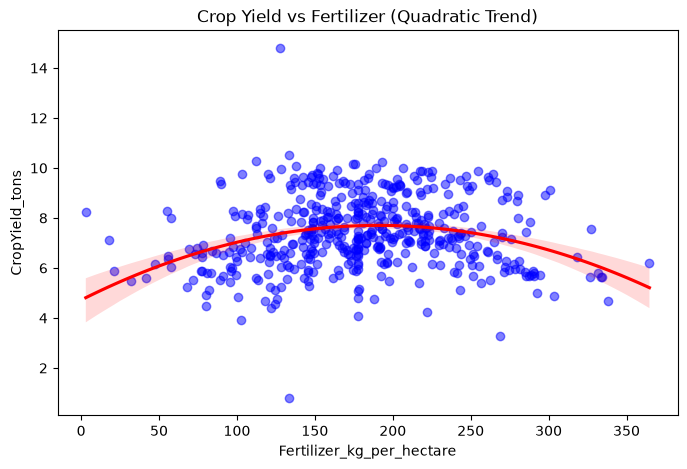

In [3]:
plt.figure(figsize=(8, 5))
# order=2 tells seaborn to fit a degree 2 polynomial line
sns.regplot(data=df, x="Fertilizer_kg_per_hectare", y="CropYield_tons", 
            scatter_kws={"alpha":0.5, "color":"blue"}, 
            line_kws={"color":"red"}, order=2)
plt.title("Crop Yield vs Fertilizer (Quadratic Trend)")
plt.show()

In [6]:
# Set X (now 2 columns!) and y
X = df[['Fertilizer_kg_per_hectare', 'CropType_Encoded']]
y = df['CropYield_tons']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Try Degree 2
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)

# Fit and transform X_train and X_test
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# See what features were created!
print("\nPolynomial Features created:")
print(poly.get_feature_names_out(X.columns))

# Train Model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict and Evaluate
y_pred = model.predict(X_test_poly)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nDegree {degree} with CropType -> MAE: {mae:.3f} | R2 Score: {r2:.3f}")


Polynomial Features created:
['Fertilizer_kg_per_hectare' 'CropType_Encoded'
 'Fertilizer_kg_per_hectare^2'
 'Fertilizer_kg_per_hectare CropType_Encoded' 'CropType_Encoded^2']

Degree 2 with CropType -> MAE: 0.631 | R2 Score: 0.700


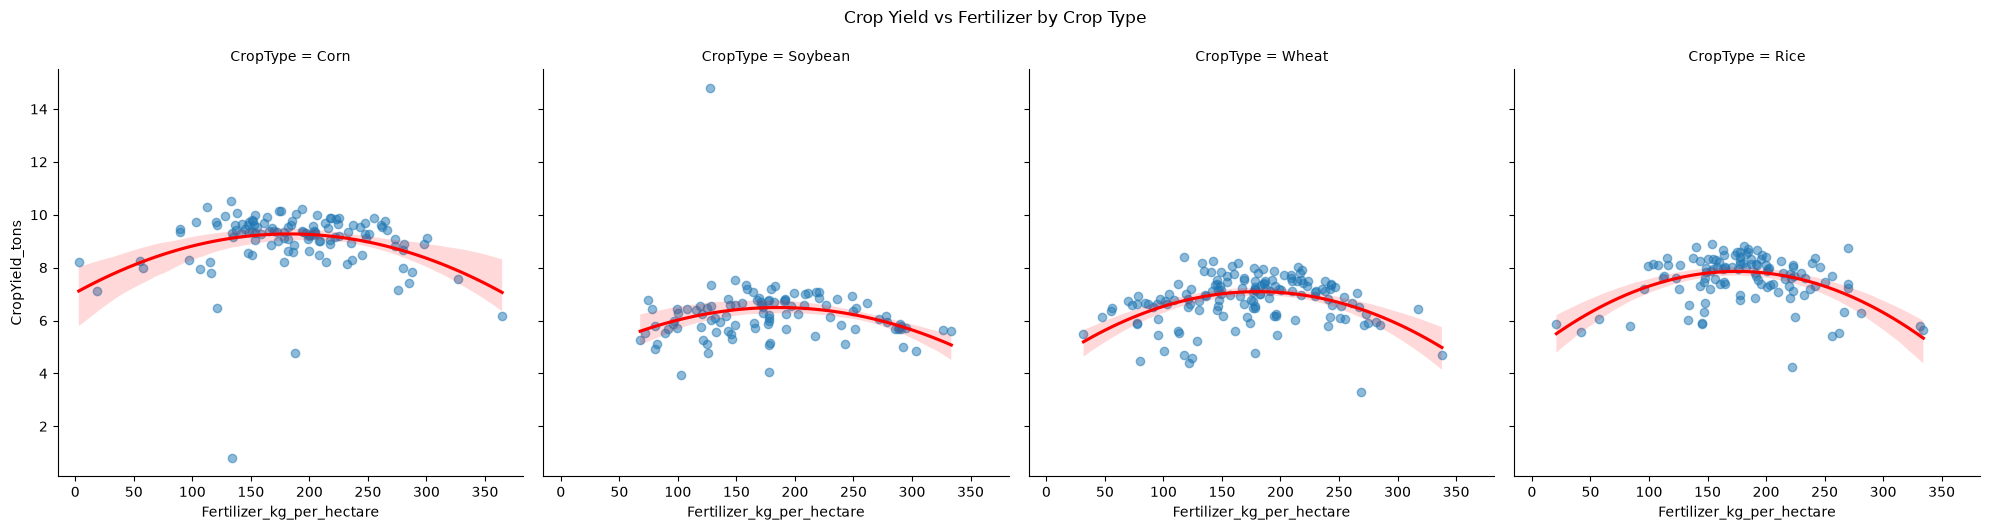

In [20]:
# We use seaborn's lmplot. 
# col='CropType' tells seaborn to make a separate chart for each crop.
# order=2 tells it to use a polynomial curve.
sns.lmplot(data=df, x="Fertilizer_kg_per_hectare", y="CropYield_tons", 
           col="CropType", order=2, line_kws={"color": "red"}, scatter_kws={"alpha":0.5})

plt.suptitle("Crop Yield vs Fertilizer by Crop Type", y=1.05)
plt.show()

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [10]:
# 1. Load and clean (Same as before)
df = pd.read_csv("crop_yield_polynomial_regression.csv")
df = df.dropna(axis=1, how='all')
df.columns = df.columns.str.strip()

num_cols = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare', 'CropYield_tons']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['CropYield_tons'])

for col in ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare']:
    df[col] = df[col].fillna(df[col].median())

df = df[df['Fertilizer_kg_per_hectare'] >= 0]
df = df[df['Fertilizer_kg_per_hectare'] <= 400]
df = df[df['Water_mm_per_season'] >= 0]
df = df[df['Water_mm_per_season'] <= 2000]
df = df[df['CropYield_tons'] > 0]

# ---------------------------------------------------------
# NEW STEP: ONE-HOT ENCODING (Dummies)
# ---------------------------------------------------------
# drop_first=True is important. If we have Corn, Rice, Wheat, Soybean, 
# we only need 3 dummy columns. If all 3 are 0, the model knows it must be Corn.
# This prevents the "Dummy Variable Trap" (multicollinearity).
df['CropType_Original'] = df['CropType']
df = pd.get_dummies(df, columns=['CropType'], drop_first=True, dtype=int)

print("Columns in our DataFrame now:")
print(df.columns.tolist())

Columns in our DataFrame now:
['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare', 'CropYield_tons', 'CropType_Original', 'CropType_Rice', 'CropType_Soybean', 'CropType_Wheat']


In [11]:
# X now includes Fertilizer and the 3 Crop Types (Corn is the baseline we dropped)
X = df[['Fertilizer_kg_per_hectare', 'CropType_Rice', 'CropType_Soybean', 'CropType_Wheat']]
y = df['CropYield_tons']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Try Degree 2
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Let's look at the new features the model is using!
print("\nFeatures created by PolynomialFeatures:")
print(poly.get_feature_names_out(X.columns))


Features created by PolynomialFeatures:
['Fertilizer_kg_per_hectare' 'CropType_Rice' 'CropType_Soybean'
 'CropType_Wheat' 'Fertilizer_kg_per_hectare^2'
 'Fertilizer_kg_per_hectare CropType_Rice'
 'Fertilizer_kg_per_hectare CropType_Soybean'
 'Fertilizer_kg_per_hectare CropType_Wheat' 'CropType_Rice^2'
 'CropType_Rice CropType_Soybean' 'CropType_Rice CropType_Wheat'
 'CropType_Soybean^2' 'CropType_Soybean CropType_Wheat' 'CropType_Wheat^2']


In [12]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nDegree {degree} with One-Hot Encoding -> MAE: {mae:.3f} | R2 Score: {r2:.3f}")


Degree 2 with One-Hot Encoding -> MAE: 0.603 | R2 Score: 0.719


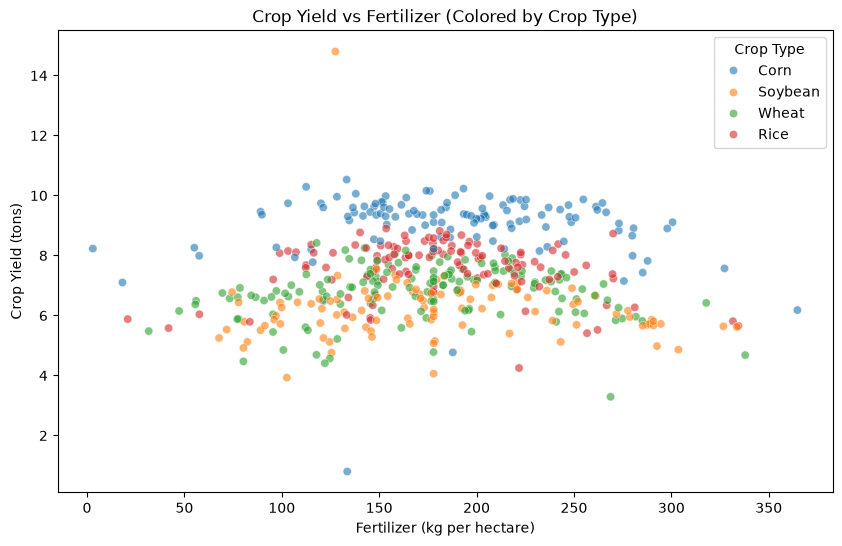

In [14]:
plt.figure(figsize=(10, 6))
# We plot the original df, coloring by CropType
sns.scatterplot(data=df, x="Fertilizer_kg_per_hectare", y="CropYield_tons", 
                hue="CropType_Original", alpha=0.6) # hue colors by crop!

# Add titles and labels
plt.title("Crop Yield vs Fertilizer (Colored by Crop Type)")
plt.xlabel("Fertilizer (kg per hectare)")
plt.ylabel("Crop Yield (tons)")
plt.legend(title="Crop Type")
plt.show()

In [21]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [23]:
# 1. Load data
df = pd.read_csv("crop_yield_polynomial_regression.csv", sep=',', engine='python')
df = df.dropna(axis=1, how='all')
df.columns = df.columns.str.strip()

# 2. Convert numbers to float
num_cols = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare', 'CropYield_tons']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Drop missing Yield
df = df.dropna(subset=['CropYield_tons'])

# 4. Fill missing Features with median
for col in ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare']:
    df[col] = df[col].fillna(df[col].median())

# 5. Remove Outliers (Added Pesticide limits!)
df = df[df['Fertilizer_kg_per_hectare'] >= 0]
df = df[df['Fertilizer_kg_per_hectare'] <= 400]
df = df[df['Water_mm_per_season'] >= 0]
df = df[df['Water_mm_per_season'] <= 2000]
df = df[df['Pesticide_L_per_hectare'] >= 0]   # Remove negative pesticide
df = df[df['Pesticide_L_per_hectare'] <= 15]  # Remove crazy high pesticide outliers (like 75)
df = df[df['CropYield_tons'] > 0]

# 6. One-Hot Encoding for Crop Type
df = pd.get_dummies(df, columns=['CropType'], drop_first=True, dtype=int)

print("Data fully cleaned! Shape:", df.shape)

Data fully cleaned! Shape: (483, 7)


In [24]:
# X now includes all our numeric features and the 3 Crop Type dummies
features = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare', 
            'CropType_Rice', 'CropType_Soybean', 'CropType_Wheat']

X = df[features]
y = df['CropYield_tons']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Try Degree 2
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Let's see how many features were created! (It will be a lot more than 6)
print(f"\nOriginal features: {len(features)}")
print(f"Polynomial features created: {X_train_poly.shape[1]}")


Original features: 6
Polynomial features created: 27


In [25]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nDegree {degree} with ALL features -> MAE: {mae:.3f} | R2 Score: {r2:.3f}")


Degree 2 with ALL features -> MAE: 0.393 | R2 Score: 0.775


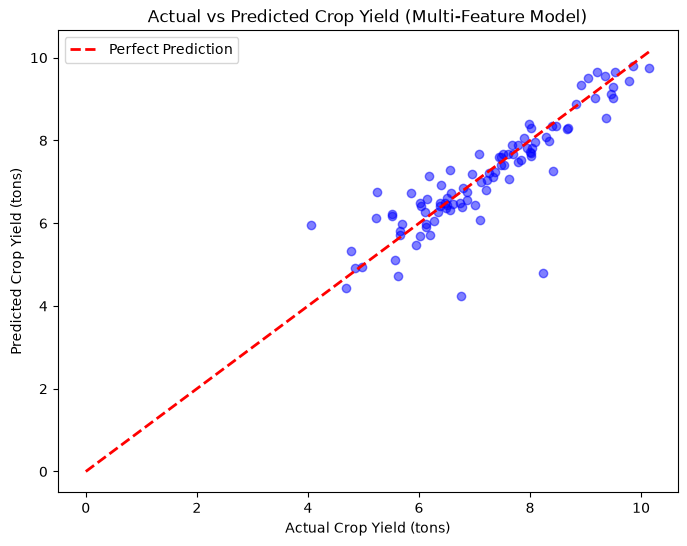

In [26]:
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')

# Draw a perfect prediction line (y = x)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Crop Yield (tons)")
plt.ylabel("Predicted Crop Yield (tons)")
plt.title("Actual vs Predicted Crop Yield (Multi-Feature Model)")
plt.legend()
plt.show()

In [28]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [30]:
# 1. Load data
df = pd.read_csv("crop_yield_polynomial_regression.csv")
df = df.dropna(axis=1, how='all')
df.columns = df.columns.str.strip()

# 2. Convert numbers to float
num_cols = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare', 'CropYield_tons']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Drop missing Yield
df = df.dropna(subset=['CropYield_tons'])

# 4. Fill missing Features with median
for col in ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare']:
    df[col] = df[col].fillna(df[col].median())

# 5. Remove Outliers (Added Pesticide limits!)
df = df[df['Fertilizer_kg_per_hectare'] >= 0]
df = df[df['Fertilizer_kg_per_hectare'] <= 400]
df = df[df['Water_mm_per_season'] >= 0]
df = df[df['Water_mm_per_season'] <= 2000]
df = df[df['Pesticide_L_per_hectare'] >= 0]   # Remove negative pesticide
df = df[df['Pesticide_L_per_hectare'] <= 15]  # Remove crazy high pesticide outliers (like 75)
df = df[df['CropYield_tons'] > 0]

# 6. One-Hot Encoding for Crop Type
df = pd.get_dummies(df, columns=['CropType'], drop_first=True, dtype=int)

print("Data fully cleaned! Shape:", df.shape)

Data fully cleaned! Shape: (483, 7)


In [36]:
# X now includes all our numeric features and the 3 Crop Type dummies
features = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare', 
            'CropType_Rice', 'CropType_Soybean', 'CropType_Wheat']

X = df[features]
y = df['CropYield_tons']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Try Degree 2
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Let's see how many features were created! (It will be a lot more than 6)
print(f"\nOriginal features: {len(features)}")
print(f"Polynomial features created: {X_train_poly.shape[1]}")


Original features: 6
Polynomial features created: 27


In [40]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nDegree {degree} with ALL features -> MAE: {mae:.3f} | R2 Score: {r2:.3f}")


Degree 2 with ALL features -> MAE: 0.387 | R2 Score: 0.813


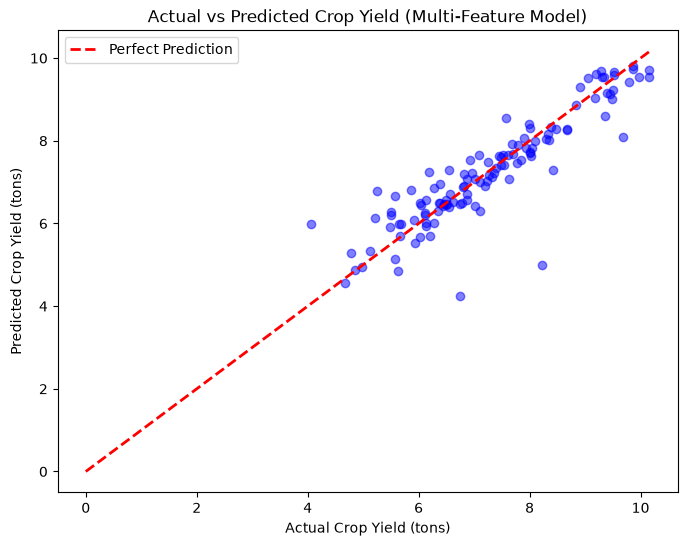

In [38]:
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')

# Draw a perfect prediction line (y = x)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Crop Yield (tons)")
plt.ylabel("Predicted Crop Yield (tons)")
plt.title("Actual vs Predicted Crop Yield (Multi-Feature Model)")
plt.legend()
plt.show()

In [41]:
# Let's store our results in a list to turn into a table later
results = []

# Loop through degrees 1 to 5
for degree in range(1, 6):
    
    # 1. Create Polynomial Features for this specific degree
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # 2. Train the model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # 3. Get Predictions and Scores for BOTH Train and Test
    y_pred = model.predict(X_test_poly)
    
    # .score() automatically calculates the R2 score
    train_r2 = model.score(X_train_poly, y_train)
    test_r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # 4. Save the results
    results.append({
        'Degree': degree,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'MAE': mae,
        'Features Created': X_train_poly.shape[1]
    })

# Convert our results into a nice DataFrame to view them
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 Degree  Train R2  Test R2      MAE  Features Created
      1  0.498444 0.619043 0.662243                 6
      2  0.715155 0.812862 0.386819                27
      3  0.639021 0.737167 0.505252                83
      4  0.564199 0.582467 0.603736               209
      5  0.481224 0.557110 0.681573               461


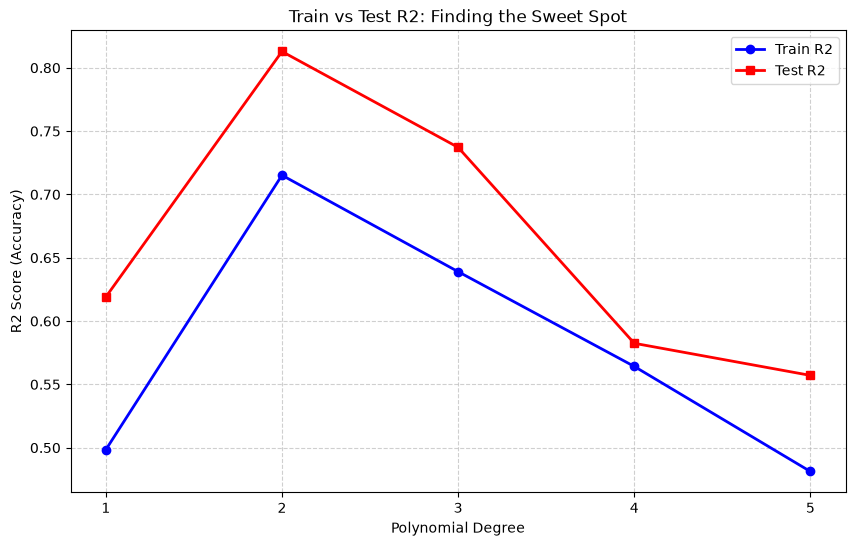

In [42]:
plt.figure(figsize=(10, 6))

# Plot Train R2 (Blue line)
plt.plot(results_df['Degree'], results_df['Train R2'], 'o-', color='blue', label='Train R2', linewidth=2)

# Plot Test R2 (Red line)
plt.plot(results_df['Degree'], results_df['Test R2'], 's-', color='red', label='Test R2', linewidth=2)

# Add labels and title
plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score (Accuracy)")
plt.title("Train vs Test R2: Finding the Sweet Spot")
plt.xticks(range(1, 6)) # Force x-axis to show 1, 2, 3, 4, 5
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler # ADDED StandardScaler for huge maths
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [44]:
# 1. Load data
df = pd.read_csv("crop_yield_polynomial_regression.csv")
df = df.dropna(axis=1, how='all')
df.columns = df.columns.str.strip()

# 2. Convert numbers to float
num_cols = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare', 'CropYield_tons']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Drop missing Yield
df = df.dropna(subset=['CropYield_tons'])

# 4. Fill missing Features with median
for col in ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare']:
    df[col] = df[col].fillna(df[col].median())

# 5. Remove Outliers (Added Pesticide limits!)
df = df[df['Fertilizer_kg_per_hectare'] >= 0]
df = df[df['Fertilizer_kg_per_hectare'] <= 400]
df = df[df['Water_mm_per_season'] >= 0]
df = df[df['Water_mm_per_season'] <= 2000]
df = df[df['Pesticide_L_per_hectare'] >= 0]   # Remove negative pesticide
df = df[df['Pesticide_L_per_hectare'] <= 15]  # Remove crazy high pesticide outliers (like 75)
df = df[df['CropYield_tons'] > 0]

# 6. One-Hot Encoding for Crop Type
df = pd.get_dummies(df, columns=['CropType'], drop_first=True, dtype=int)

print("Data fully cleaned! Shape:", df.shape)

Data fully cleaned! Shape: (483, 7)


In [45]:
# X now includes all our numeric features and the 3 Crop Type dummies
features = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare', 
            'CropType_Rice', 'CropType_Soybean', 'CropType_Wheat']

X = df[features]
y = df['CropYield_tons']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Try Degree 2
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Let's see how many features were created! (It will be a lot more than 6)
print(f"\nOriginal features: {len(features)}")
print(f"Polynomial features created: {X_train_poly.shape[1]}")


Original features: 6
Polynomial features created: 27


 Degree  Train R2   Test R2      MAE  Features Created
      1  0.498444  0.619043 0.662243                 6
      2  0.733466  0.849866 0.357611                27
      3  0.747396  0.851721 0.389847                83
      4  0.770049  0.699351 0.492118               209
      5  0.812974 -5.793530 1.507485               461


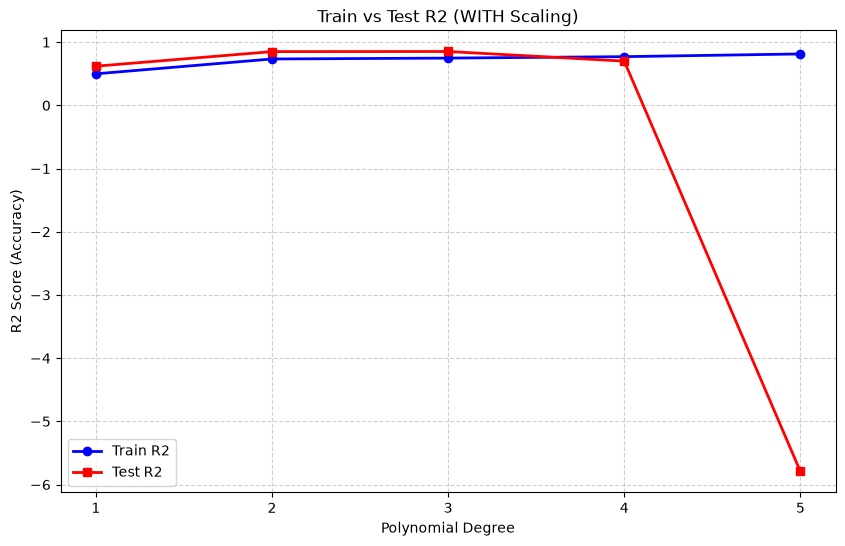

In [46]:
results = []

for degree in range(1, 6):
    
    # 1. Create Polynomial Features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # 2. NEW: Scale the features so the math doesn't break!
    scaler = StandardScaler()
    X_train_poly_scaled = scaler.fit_transform(X_train_poly)
    X_test_poly_scaled = scaler.transform(X_test_poly)
    
    # 3. Train the model on the SCALED data
    model = LinearRegression()
    model.fit(X_train_poly_scaled, y_train)
    
    # 4. Predict and Score
    y_pred = model.predict(X_test_poly_scaled)
    
    train_r2 = model.score(X_train_poly_scaled, y_train)
    test_r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Degree': degree,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'MAE': mae,
        'Features Created': X_train_poly.shape[1]
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot it again to see the classic "Overfitting" curve
plt.figure(figsize=(10, 6))
plt.plot(results_df['Degree'], results_df['Train R2'], 'o-', color='blue', label='Train R2', linewidth=2)
plt.plot(results_df['Degree'], results_df['Test R2'], 's-', color='red', label='Test R2', linewidth=2)
plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score (Accuracy)")
plt.title("Train vs Test R2 (WITH Scaling)")
plt.xticks(range(1, 6))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()